# Generate the dataset

In [40]:
import random

In [41]:
# number of blocks ( = number of goals )
N = 3
# block size (in [m])
block_size = 0.2
# whether initial positions are in a tower or scattered around
initial_tower = True

In [42]:
# 1. Generate random order for the goals
idx_goals = [i for i in range(0, N)]
random.shuffle(idx_goals)

# 2. Generate initial order for the blocks by inverting the order of goals
idx_objs = idx_goals[::-1]

# 3. Generate goals
# https://www.generationrobots.com/media/panda-franka-emika-datasheet.pdf
# according to the datasheet, the Franka Panda can reach in an area of 0.855 [m] around itself
max_reach_dist = 0.7 # [m]

# select a random (x,y) position for the goal.
x_goal = random.random() * max_reach_dist
y_goal = random.random() * max_reach_dist

pos_goals = [(x_goal, y_goal, i*block_size) for i in range(0, N)]

# Generate initial positions
if initial_tower:
    x_obj = random.random() * max_reach_dist
    y_obj = random.random() * max_reach_dist

    pos_objects = [(x_obj, y_obj, i*block_size) for i in range(0, N)]
else:
    pos_objects = [(random.random() * max_reach_dist, random.random() * max_reach_dist, i*block_size) for i in range(0, N)]

goals = {}
objects = {}
for i in range(0, N):
    goals[idx_goals[i]] = pos_goals[i]
    objects[idx_objs[i]] = pos_objects[i]

print(f"goals (in desired order of final stacking):\n{goals}")
print(f"initial object positions (in order of stacking):\n{objects}")


goals (in desired order of final stacking):
{1: (0.5566738101510117, 0.4519847915450797, 0.0), 0: (0.5566738101510117, 0.4519847915450797, 0.2), 2: (0.5566738101510117, 0.4519847915450797, 0.4)}
initial object positions (in order of stacking):
{2: (0.3824360584271401, 0.2707323454934634, 0.0), 0: (0.3824360584271401, 0.2707323454934634, 0.2), 1: (0.3824360584271401, 0.2707323454934634, 0.4)}


In [43]:
# Now solve the stacking problem by taking the highest block in the objects tower (last in order)
# and putting it into the lowest available goal (first in order)

tau = []

# build the state vector, ordered nodes with categorical, position and binary features, followed by ordered goals with the same features
def build_state(objects, goals):
    s = []
    for n in range(0, N):
        s.append(1) # objects are all blocks
        for o in objects[n]: s.append(o)
        # s.append(objects[n]) # position of block
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    for n in range(0, N):
        s.append(2) # goals
        # s.append(goals[n]) # position of block
        for o in goals[n]: s.append(o)
        s.append(int(objects[n] == goals[n])) # whether block is in goal

    return s
        
tau.append(build_state(objects, goals))

for n in range(0, N):
    print(f"step #{n}")
    
    o = N-1-n

    print(f"choosing object #{idx_objs[o]} with pos {objects[idx_objs[o]]}")
    print(f"moving object #{idx_objs[o]} to goal{goals[idx_objs[o]]}")

    objects[idx_objs[o]] = goals[idx_objs[o]]
    tau.append([o, o])

    print(f"Updated object positions with goals:")
    print(f"goals:\n{goals}")
    print(f"current objects pos:\n{objects}")
    print("\n")


    tau.append(build_state(objects, goals))

print(tau)

step #0
choosing object #1 with pos (0.3824360584271401, 0.2707323454934634, 0.4)
moving object #1 to goal(0.5566738101510117, 0.4519847915450797, 0.0)
Updated object positions with goals:
goals:
{1: (0.5566738101510117, 0.4519847915450797, 0.0), 0: (0.5566738101510117, 0.4519847915450797, 0.2), 2: (0.5566738101510117, 0.4519847915450797, 0.4)}
current objects pos:
{2: (0.3824360584271401, 0.2707323454934634, 0.0), 0: (0.3824360584271401, 0.2707323454934634, 0.2), 1: (0.5566738101510117, 0.4519847915450797, 0.0)}


step #1
choosing object #0 with pos (0.3824360584271401, 0.2707323454934634, 0.2)
moving object #0 to goal(0.5566738101510117, 0.4519847915450797, 0.2)
Updated object positions with goals:
goals:
{1: (0.5566738101510117, 0.4519847915450797, 0.0), 0: (0.5566738101510117, 0.4519847915450797, 0.2), 2: (0.5566738101510117, 0.4519847915450797, 0.4)}
current objects pos:
{2: (0.3824360584271401, 0.2707323454934634, 0.0), 0: (0.5566738101510117, 0.4519847915450797, 0.2), 1: (0.5566

In [44]:
# Alternatevely
# at each step, find the highest block that is not yet in its goal
# and move it to the lowest available goal
# repeat until each blocks is in its goal

# Observation to graph

In [45]:
# Now put the demonstration in graph format, using pytorch geometric

import torch_geometric
import torch
from torch_geometric.utils.convert import to_networkx
import networkx as nx


s0 = tau[0]
print(s0)

x = torch.reshape(torch.tensor(s0), (N*2, -1)) # N*2 considers both goals and blocks
print(x)

# graphs are always fully connected, undirected, and with no edge features
edges = []
for i in range(0, N*2):
    for j in range(0, N*2):
        edges.append([i,j])
print(edges)

# torch_geometric.data.Data is a single graph
# x is the input graph, as a matrix of dimension [node, node_features]
# I have N*2 nodes (N blocks, N goals) and 5 features each
G = torch_geometric.data.Data(x=x, edge_index=torch.tensor(edges).t().contiguous())


[1, 0.3824360584271401, 0.2707323454934634, 0.2, 0, 1, 0.3824360584271401, 0.2707323454934634, 0.4, 0, 1, 0.3824360584271401, 0.2707323454934634, 0.0, 0, 2, 0.5566738101510117, 0.4519847915450797, 0.2, 0, 2, 0.5566738101510117, 0.4519847915450797, 0.0, 0, 2, 0.5566738101510117, 0.4519847915450797, 0.4, 0]
tensor([[1.0000, 0.3824, 0.2707, 0.2000, 0.0000],
        [1.0000, 0.3824, 0.2707, 0.4000, 0.0000],
        [1.0000, 0.3824, 0.2707, 0.0000, 0.0000],
        [2.0000, 0.5567, 0.4520, 0.2000, 0.0000],
        [2.0000, 0.5567, 0.4520, 0.0000, 0.0000],
        [2.0000, 0.5567, 0.4520, 0.4000, 0.0000]])
[[0, 0], [0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [1, 0], [1, 1], [1, 2], [1, 3], [1, 4], [1, 5], [2, 0], [2, 1], [2, 2], [2, 3], [2, 4], [2, 5], [3, 0], [3, 1], [3, 2], [3, 3], [3, 4], [3, 5], [4, 0], [4, 1], [4, 2], [4, 3], [4, 4], [4, 5], [5, 0], [5, 1], [5, 2], [5, 3], [5, 4], [5, 5]]


[array([1.        , 0.43363863, 0.5680763 , 0.2       , 0.        ],
      dtype=float32), array([1.        , 0.43363863, 0.5680763 , 0.        , 0.        ],
      dtype=float32), array([1.        , 0.43363863, 0.5680763 , 0.4       , 0.        ],
      dtype=float32), array([2.        , 0.46023884, 0.41609505, 0.2       , 0.        ],
      dtype=float32), array([2.        , 0.46023884, 0.41609505, 0.4       , 0.        ],
      dtype=float32), array([2.        , 0.46023884, 0.41609505, 0.        , 0.        ],
      dtype=float32)]


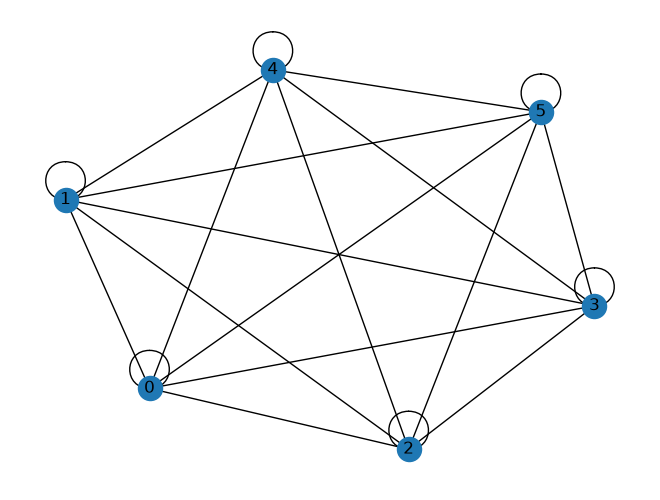

In [ ]:
node_labels = [G.x[i, :].numpy() for i in range(0, N*2)]
print(features)

g = torch_geometric.utils.to_networkx(G, to_undirected=True)
nx.draw(g, with_labels=True)